In [4]:
%load_ext autoreload
%autoreload 2
from superbit_lensing.plotter import ClusterRedSequenceAnalysis
import superbit_lensing.utils as utils
import os

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
cluster_name = 'Abell3411'
# datadir = "/scratch/sa.saha/data" #Change to your data directory!
datadir = "/Users/leilaohashi/superbit-lensing/data"
#datafilename = "home/filename.fits"
utils.TARGET_LIST = os.path.join(datadir, "SuperBIT_target_list.csv")
analyzer = ClusterRedSequenceAnalysis(cluster_name, datadir=datadir, delz=0.02)
analyzer.load_data()

Galaxies with z > 0.19: 55
Galaxies with 0.15 < z ≤ 0.19: 171
Galaxies with z ≤ 0.15: 1


Number of objects in the red sequence: 1102


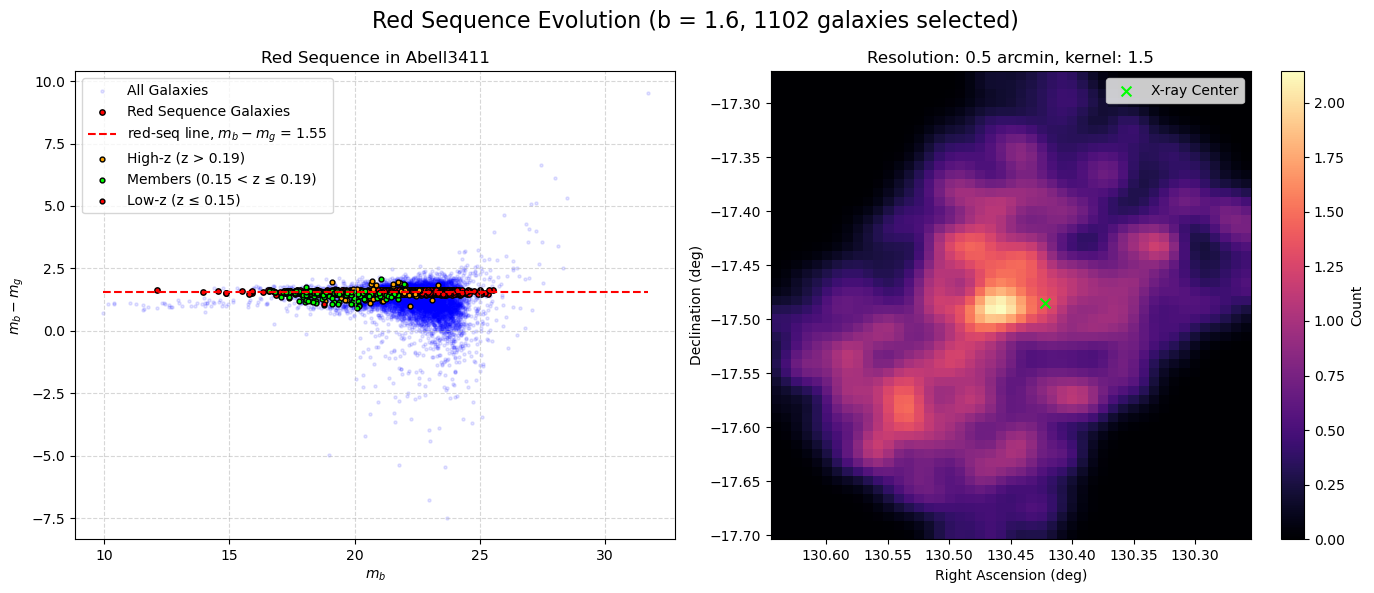

In [9]:
analyzer.compute_red_sequence(a=0.0, b=1.55, tolerance=0.1, resolution=0.5, sigma=1.5, save_path = "")

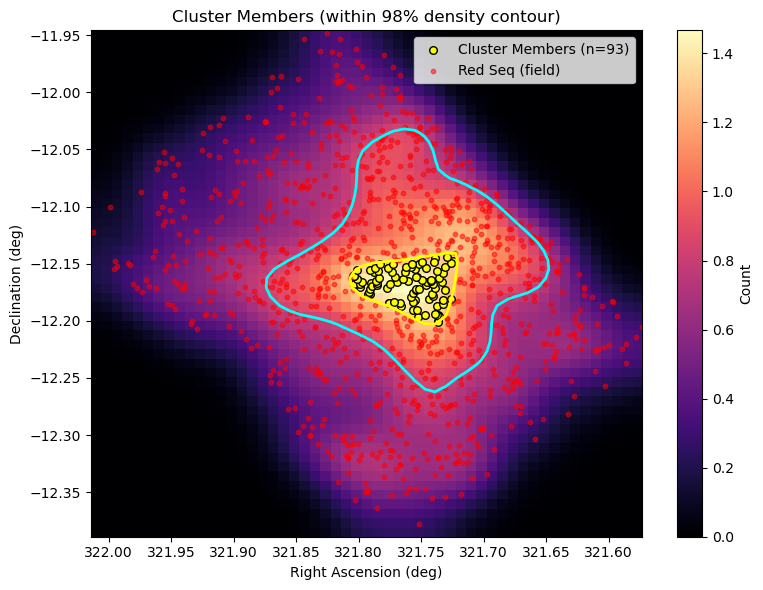


Cluster Member Selection Summary:
Total red sequence galaxies: 1058
Galaxies within cluster contour: 93
Fraction in cluster: 8.8%


In [ ]:
cluster_catalog = analyzer.identify_cluster_members(percentiles=[85, 98], sigma_smooth=2.5)

In [ ]:
# analyzer.save_cluster_catalog()
# analyzer.update_original_catalog()

Saved cluster member catalog to: /scratch/sa.saha/data/Abell2345/sextractor_dualmode/out/Abell2345_coadd_redseq.fits
Total cluster members saved: 93
Updated original catalog: /scratch/sa.saha/data/Abell2345/sextractor_dualmode/out/Abell2345_colors_mags.fits
Total red sequence galaxies marked: 1058
Total cluster members marked: 93


In [ ]:
save_path = f"/Users/leilaohashi/superbit-lensing/notebooks/leila/{cluster_name}"
_ = analyzer._make_rgb_image(red_boost_factor=1.1, green_supression=0.9, blue_suppression=0.9, dpi=1200, save_path=save_path, mark_members=True)

Creating RGB image using:
  U band: /Users/leilaohashi/superbit-lensing/data/Abell3411/sextractor_dualmode/coadd/u/Abell3411_coadd_u.fits
  B band: /Users/leilaohashi/superbit-lensing/data/Abell3411/sextractor_dualmode/coadd/b/Abell3411_coadd_b.fits
  G band: /Users/leilaohashi/superbit-lensing/data/Abell3411/sextractor_dualmode/coadd/g/Abell3411_coadd_g.fits


AttributeError: 'ClusterRedSequenceAnalysis' object has no attribute 'cluster_catalog'

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


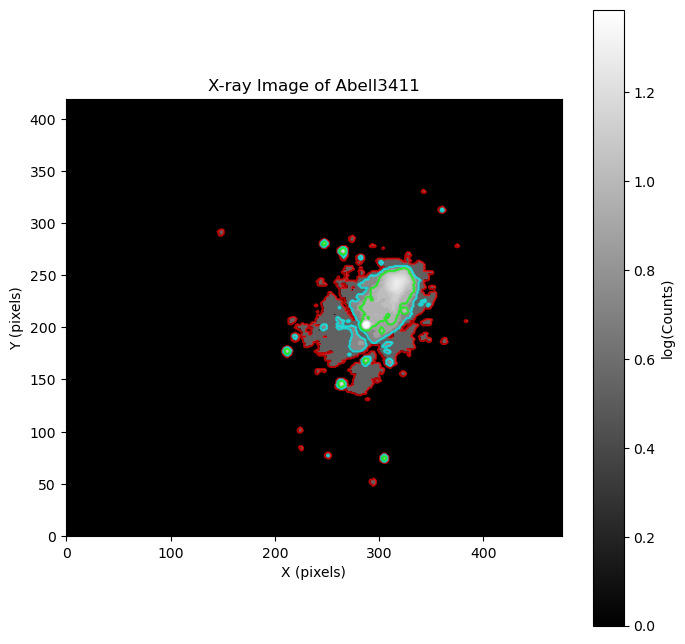

X-ray image saved to /Users/leilaohashi/leila/x_ray_image/Abell3411/Abell3411_xray_image.png


In [46]:

import os
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np
from scipy.ndimage import gaussian_filter

cluster_name = "Abell3411"

fits_path = f"/Users/leilaohashi/leila/data/xray/{cluster_name}_xray_image.fits"
if not os.path.exists(fits_path):
    print(f"X-ray image for {cluster_name} not found at {fits_path}.")

# Open the image
xray_hdu = fits.open(fits_path)[0]
xray_data = xray_hdu.data
xray_data = np.array(xray_data)
print(xray_data)

# Plot the image
smoothed_counts = gaussian_filter(xray_data, sigma=2)
log_image = np.log1p(smoothed_counts)
vmin, vmax = np.percentile(log_image, [1, 99])
plt.figure(figsize=(8, 8))
plt.imshow(np.log1p(log_image), origin='lower', cmap='gray', vmin=vmin, vmax=vmax)
plt.colorbar(label='log(Counts)')
plt.title(f'X-ray Image of {cluster_name}')
plt.xlabel('X (pixels)')
plt.ylabel('Y (pixels)')

# Contours
contour_levels = np.linspace(np.percentile(log_image, 70), np.percentile(log_image,99), 3)
# Contour Colors
colors = ['red', 'cyan', 'lime']
plt.contour(log_image, levels=contour_levels, colors=colors, linewidths=1.5, alpha=0.7)

# Save and show the image
save_path = f"/Users/leilaohashi/leila/x_ray_image/{cluster_name}/{cluster_name}_xray_image.png"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, dpi=300)
plt.show()

print(f"X-ray image saved to {save_path}")

In [45]:
from astropy.io import fits
fits_path = "/Users/leilaohashi/superbit-lensing/data/xray/Abell3411_xray_image.fits"
hdul = fits.open(fits_path)
hdul.info()

Filename: /Users/leilaohashi/superbit-lensing/data/xray/Abell3411_xray_image.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     935   (476, 420)   int32   
  1  GTI           3 BinTableHDU     28   5R x 2C   [1D, 1D]   
  2  GTI           2 BinTableHDU     28   2R x 2C   [1D, 1D]   
  3  GTI           1 BinTableHDU     28   3R x 2C   [1D, 1D]   
  4  GTI           0 BinTableHDU     28   1R x 2C   [1D, 1D]   
  5  GTI           6 BinTableHDU     28   2R x 2C   [1D, 1D]   


In [51]:
from astropy.table import Table, vstack, hstack
import numpy as np
from esutil import htm
import os

cluster_name = "Abell3411"
color_path = "/Users/leilaohashi/leila/data/color_mags/"
mcal_path = "/Users/leilaohashi/leila/data/mcal/"

color_cat_path = os.path.join(
    color_path, cluster_name, f"{cluster_name}_colors_mags.fits")
mcal_cat_path = os.path.join(
    mcal_path, cluster_name, f"{cluster_name}_b_mcal_combined.fits")

colors_mags = Table.read(color_cat_path, memmap=True)
mcal = Table.read(mcal_cat_path, memmap=True)

mcal_matcher = htm.Matcher(16, ra=mcal['ra'], dec=mcal['dec'])

colors_ind, mcal_ind, dist = mcal_matcher.match(
    ra=colors_mags['ra'], dec=colors_mags['dec'],
    maxmatch=1, radius=0.8/3600)
print(len(dist))

mcal = mcal[mcal_ind]
colors_mags = colors_mags[colors_ind]

g1 = mcal['g_noshear'][:,0]
g2 = mcal['g_noshear'][:,1]
colors_mags.add_columns([g1, g2], names=["g1_noshear", "g2_noshear"])
 
wg = colors_mags['is_cluster_member']
print(np.sum(wg))

outname = os.path.splitext(color_cat_path)[0] + '_clean_nors.fits'
colors_mags[wg].write(outname, format='fits', overwrite=True)

8652
83


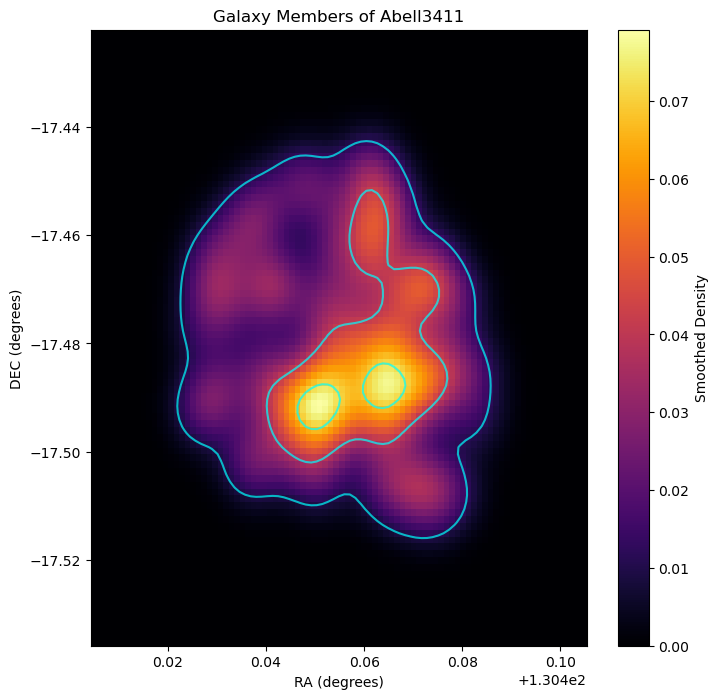

Actual members plot saved to /Users/leilaohashi/leila/members_graph/Abell3411/Abell3411_actual_members.png


In [159]:
import os
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np
from scipy.ndimage import gaussian_filter

am_path = f"/Users/leilaohashi/leila/data/color_mags/{cluster_name}/{cluster_name}_colors_mags_clean_nors.fits"
if not os.path.exists(am_path):
    print(f"Actual members file for {cluster_name} not found at {am_path}.")

# Open the image
actual_members_hdu = fits.open(am_path)[1]
actual_members_data = actual_members_hdu.data

# Get RA and DEC
ra = actual_members_data['RA']
dec = actual_members_data['DEC']

# 2D histogram
counts, xedges, yedges = np.histogram2d(ra, dec, bins=50) # change bins here
# do 5 galaxies per bin

# Padding
pad = 20
padded_counts = np.pad(counts, pad_width=pad, mode='constant', constant_values=0)

# Smoothing
smoothed_padded_counts = gaussian_filter(padded_counts, sigma=4)

# Plot smoothed histogram
plt.figure(figsize=(8, 8))
nx, ny = smoothed_padded_counts.shape
dx = xedges[1] - xedges[0]
dy = yedges[1] - yedges[0]
xedges_padded = np.linspace(xedges[0] - pad * dx, xedges[-1] + pad * dx, smoothed_padded_counts.shape[0] + 1)
yedges_padded = np.linspace(yedges[0] - pad * dy, yedges[-1] + pad * dy, smoothed_padded_counts.shape[1] + 1)
extent = [xedges_padded[0], xedges_padded[-1], yedges_padded[0], yedges_padded[-1]]

plt.imshow(smoothed_padded_counts.T, extent=extent, origin='lower', cmap='inferno', aspect='auto', vmin=smoothed_padded_counts.min(), vmax=smoothed_padded_counts.max())
plt.colorbar(label='Smoothed Density')
plt.title(f'Galaxy Members of {cluster_name}')
plt.xlabel('RA (degrees)')
plt.ylabel('DEC (degrees)')

# Contours
contour_levels = np.linspace(np.percentile(smoothed_padded_counts, 70), np.percentile(smoothed_padded_counts,99), 3)

# Contour Colors
colors = ['cyan', 'cyan', 'cyan']
x_padded, y_padded = np.meshgrid(xedges_padded[:-1], yedges_padded[:-1])
plt.contour(x_padded, y_padded, smoothed_padded_counts.T, levels=contour_levels, colors=colors, linewidths=1.5, alpha=0.7)


# Save and show the image
save_path = f"/Users/leilaohashi/leila/members_graph/{cluster_name}/{cluster_name}_actual_members.png"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, dpi=300)
plt.show()
print(f"Actual members plot saved to {save_path}")

# save the contours
x_centers_padded = 0.5 * (xedges_padded[:-1] + xedges_padded[1:])
y_centers_padded = 0.5 * (yedges_padded[:-1] + yedges_padded[1:])
X, Y = np.meshgrid(x_centers_padded, y_centers_padded)
saved_contour_data = (X, Y, smoothed_padded_counts, contour_levels)

# histogram without padding
counts, xedges, yedges = np.histogram2d(ra, dec, bins=50) # change bins here
smoothed_counts = gaussian_filter(counts, sigma=4)
x_centers = 0.5 * (xedges[:-1] + xedges[1:])
y_centers = 0.5 * (yedges[:-1] + yedges[1:])
X, Y = np.meshgrid(x_centers, y_centers)
contour_levels = np.linspace(np.percentile(smoothed_counts, 70), np.percentile(smoothed_counts,99), 3)
# 1. load this catalogue into DS9 to see where the members are. Done!

# 2. find what bin works best yup!

# 3. plot contours on actual coadd

# upload in github - make copy of files into gitrepo


In [92]:
from astropy.io import fits
am_path = "/Users/leilaohashi/superbit-lensing/data/actual_members/Abell3411_actual_members_catalog.fits"
hdul = fits.open(am_path)
hdul.info()

FileNotFoundError: [Errno 2] No such file or directory: '/Users/leilaohashi/superbit-lensing/data/actual_members/Abell3411_actual_members_catalog.fits'

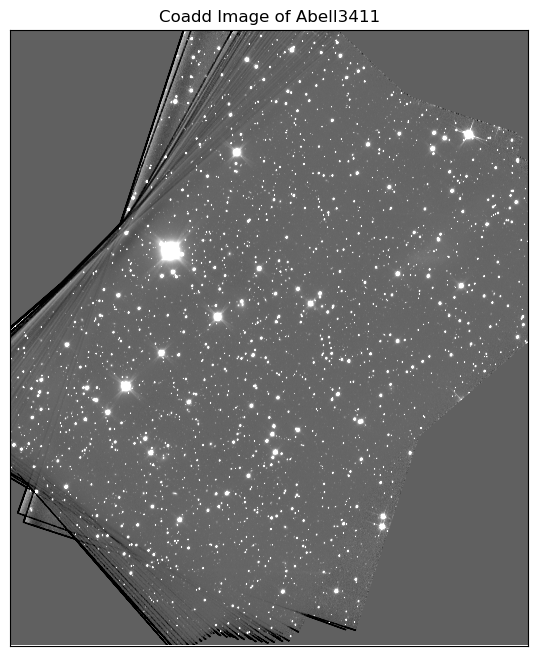

Contour RA range: 130.42727930236256 130.482365461241
Contour DEC range: -17.509912778457398 -17.447967783638777
Coadd RA range: 130.4500139721 130.4500139721
Coadd DEC range: -17.491210650400006 -17.491210650400006


In [157]:
# Plotting contours on coadd image
import os
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np
from astropy.wcs import WCS


cluster_name = "Abell3411"
fits_path = f'/Users/leilaohashi/leila/data/coadds/{cluster_name}/{cluster_name}_coadd_b.sub.fits'
if not os.path.exists(fits_path):
    print(f"Coadd image for {cluster_name} not found at {fits_path}.")
# Open the image
coadd_hdu = fits.open(fits_path)[0]
coadd_data = coadd_hdu.data
wcs = WCS(coadd_hdu.header)

# plot the image
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection=wcs)
ax.imshow(coadd_data, origin='lower', cmap='gray', vmin=np.percentile(coadd_data, 1), vmax=np.percentile(coadd_data, 99))

# matching the coordinates
ax.contour(X, Y, smoothed_counts, levels=contour_levels, colors=['cyan', 'cyan', 'cyan'], linewidths=1.5, alpha=0.7, transform=ax.get_transform('world'))
# overlay contours from actual members
ax.set_title(f'Coadd Image of {cluster_name}')
ax.set_xlabel('RA')
ax.set_ylabel('DEC')
plt.show()

print("Contour RA range:", X.min(), X.max())
print("Contour DEC range:", Y.min(), Y.max())

height, width = coadd_data.shape
corners = np.array([[0,0],[width,0],[0,height],[width,height]])
coadd_radec = wcs.wcs_pix2world(corners, 0)
print("Coadd RA range:", coadd_radec[:,0].min(), coadd_radec[:,0].max())
print("Coadd DEC range:", coadd_radec[:,1].min(), coadd_radec[:,1].max())